<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/K%20Means%20vs%20DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# import the libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score,calinski_harabasz_score
from sklearn.decomposition import PCA

In [5]:
#1.DATA PREPARATION
def load_data():
  """
    Generates a realistic synthetic Kenyan demographic dataset.
    (See the comments at the bottom of this script to learn how to load the REAL KDHS dataset).
    """
  np.random.seed(42)
  n_samples = 2000

  # Simulating 4 distinct Kenyan demographic profiles
  # Profile 1: Urban Affluent (Nairobi/Mombasa)
  p1 = pd.DataFrame({
      'Age':np.random.normal(35,8,500),
      'Household_Size': np.random.normal(3,1,500),
      'Wealth_Index':np.random.normal(4.5,0.5,500),
      'Education_Level':np.random.normal(3.8,0.4,500),
      'Residence': np.ones(500)#1=Urban
  })

  #Profile 2:Rural Large Families (Western/Nyanza)
  p2 = pd.DataFrame({
      'Age':np.random.normal(45,10,600),
      'Household_Size':np.random.normal(7,2,600),
      'Wealth_Index': np.random.normal(1.5,0.5,600),
      'Education_Level':np.random.normal(1.2,0.6,600),
      'Residence': np.zeros(600)
  })

  # Profile 3: Peri-Urban Emerging Class
  p3 = pd.DataFrame({
      'Age':np.random.normal(40,9,500),
      'Household_Size':np.random.normal(5,1.5,500),
      'Wealth_Index':np.random.normal(3.0,0.6,500),
      'Education_Level':np.random.normal(2.5,0.7,500),
      'Residence': np.ones(500)

  })

  #Profile 4:Marginalized Pastoralist Outliers
  p4 = pd.DataFrame({
      'Age':np.random.normal(30,12,400),
      'Household_Size':np.random.normal(12,4,400),
      'Wealth_Index':np.random.normal(1.0,0.8,400),
      'Education_Level':np.random.normal(0.5,0.5,400),
      'Residence': np.zeros(400)

  })

  df = pd.concat([p1,p2,p3,p4],ignore_index=True)

  #Clip values to realistic bounds
  df['Age'] = df['Age'].clip(18,90).astype(int)
  df['Household_Size'] = df['Household_Size'].clip(1,10).astype(int)
  df['Wealth_Index'] =df['Wealth_Index'].clip(1,5)
  df['Education_Level'] = df['Education_Level'].clip(0,4).astype(int)

  return df

In [6]:
df = load_data()
display(df.head())

,Age,Household_Size,Wealth_Index,Education_Level,Residence
0,38,3,5.000000,4,1.0
1,33,4,4.962317,3,1.0
2,40,1,4.529815,3,1.0
3,47,3,4.176532,3,1.0
4,33,2,4.849112,3,1.0


In [7]:
#.PREPROCESSING
print("Loading and preprocessing data...")
df = load_data()

#Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

Loading and preprocessing data...


In [9]:
#3.K-MEANS IMPLEMENTATION
print("\n---Running K-Means Clustering---")
start_time = time.time()

kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_data)

kmeans_time = time.time() - start_time
kmeans_silhouette = silhouette_score(scaled_data,kmeans_labels)
kmeans_ch = calinski_harabasz_score(scaled_data,kmeans_labels)

print(f"K-Means Runtime: {kmeans_time:.4f}seconds")
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"K-Means Calinski-Harabasz Index: {kmeans_ch:.2f}")


---Running K-Means Clustering---
K-Means Runtime: 0.0257seconds
K-Means Silhouette Score: 0.3589
K-Means Calinski-Harabasz Index: 1983.98


In [10]:
#4.DBSCAN IMPLEMENTATION
print("\---Running DBSCAN---")
start_time =time.time()

#eps is the radius,min_samplkes is the minimum points to form a dense region
dbscan = DBSCAN(eps=0.8,min_samples=15)
dbscan_labels = dbscan.fit_predict(scaled_data)

dbscan_time = time.time() - start_time
#Calculate metrics ignoring noise points(label-1)
unique_labels = set(dbscan_labels)
n_noise = list(dbscan_labels).count(-1)

if len(unique_labels) > 1 and n_noise < len(dbscan_labels):
  dbscan_silhouette = silhouette_score(scaled_data,dbscan_labels)
  dbscan_ch = calinski_harabasz_score(scaled_data,dbscan_labels)

else:
  dbscan_silhouette = 0.0
  dbscan_ch = 0.0

  print(f"DBSCAN Runtime: {dbscan_time:.4f} seconds")
print(f"DBSCAN Clusters Found: {len(unique_labels) - 1}")
print(f"DBSCAN Noise/Outliers Detected: {n_noise} ({(n_noise/len(dbscan_labels))*100:.1f}%)")
print(f"DBSCAN Silhouette Score: {dbscan_silhouette:.4f}")
print(f"DBSCAN Calinski-Harabasz Index: {dbscan_ch:.2f}")

<>:2: SyntaxWarning: invalid escape sequence '\-'
<>:2: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_766/516936572.py:2: SyntaxWarning: invalid escape sequence '\-'
  print("\---Running DBSCAN---")


\---Running DBSCAN---
DBSCAN Clusters Found: 2
DBSCAN Noise/Outliers Detected: 36 (1.8%)
DBSCAN Silhouette Score: 0.4247
DBSCAN Calinski-Harabasz Index: 1333.47



Generating visualizations..


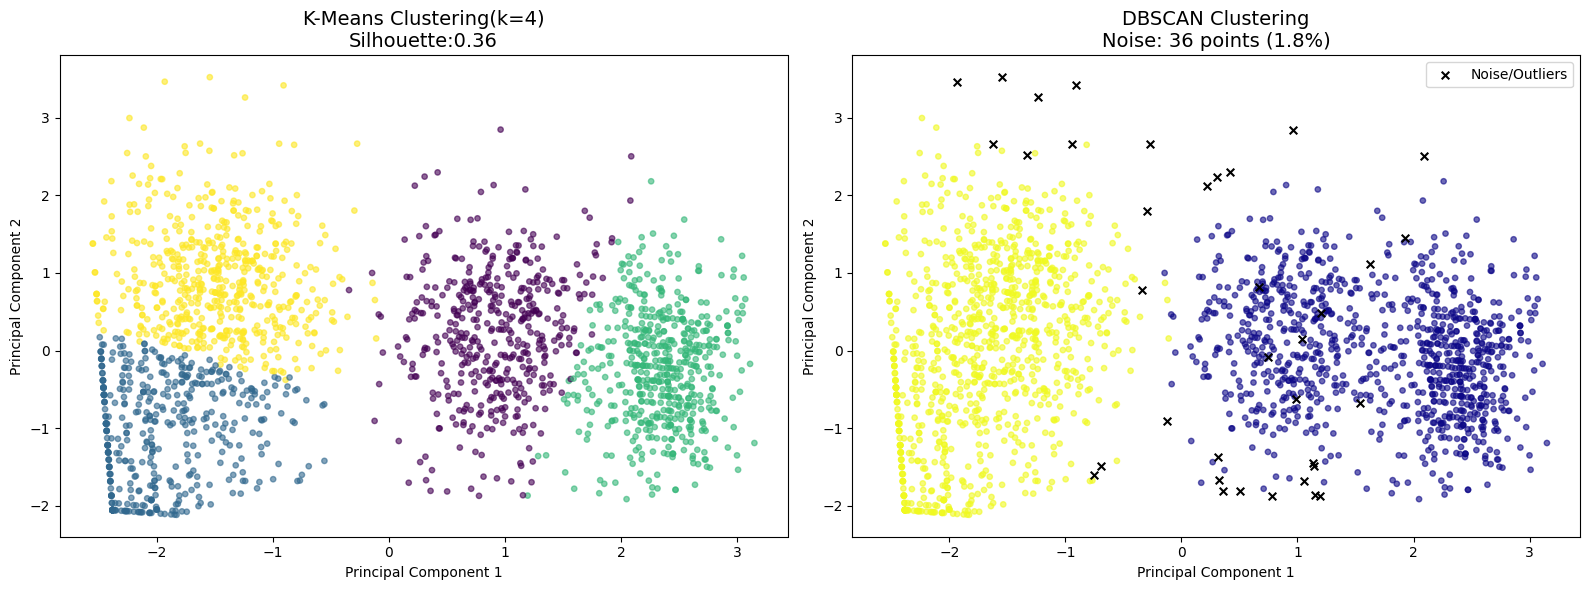


✅ Done! Check the 'kenya_clustering_results.png' image in your folder.


In [12]:
#5 VISUALIZATION (Using PCA to reduce 5D to 2D)
print("\nGenerating visualizations..")
pca = PCA(n_components = 2)
reduced_data = pca.fit_transform(scaled_data)

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(16,6))

#Plot K-Means
scatter1 = ax1.scatter(reduced_data[:,0],reduced_data[:,1],c=kmeans_labels,cmap='viridis',s=15,alpha=0.6)
ax1.set_title(f'K-Means Clustering(k=4)\nSilhouette:{kmeans_silhouette:.2f}',fontsize=14)
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
# Plot DBSCAN
colors = dbscan_labels
# Make noise points black and smaller for emphasis
mask_noise = colors == -1
scatter2 = ax2.scatter(reduced_data[~mask_noise, 0], reduced_data[~mask_noise, 1],
                       c=colors[~mask_noise], cmap='plasma', s=15, alpha=0.6)
ax2.scatter(reduced_data[mask_noise, 0], reduced_data[mask_noise, 1],
            c='black', marker='x', s=30, label='Noise/Outliers')
ax2.set_title(f'DBSCAN Clustering\nNoise: {n_noise} points ({(n_noise/len(dbscan_labels))*100:.1f}%)', fontsize=14)
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.legend()

plt.tight_layout()
plt.savefig('kenya_clustering_results.png')
plt.show()

print("\n✅ Done! Check the 'kenya_clustering_results.png' image in your folder.")